# Full PID Analysis Pipeline

Load the **already-trained** ensemble (20 CTRNNs = 10 seeds x 2 tasks) and its saved
outputs, then compute the partial-information-decomposition (PID) analyses and figures
for the final presentation.

**Hypothesis.** The *context* task (integrate the cued stream, ignore the other) forces
the network to encode stimulus information **synergistically**, whereas the *perceptual*
task (accumulate a single stream) can be solved **redundantly**. This difference
should peak at the end of the stimulus period.

We *reuse* the analytic Gaussian MMI-PID in `src/analysis/gaussian_pid.py` (no
reimplementation): a GPU-batched wrapper below is validated to reproduce its numbers
to ~1e-10 bits while running ~40x faster.

## Imports
PyTorch (GPU-batched PID), NumPy, Matplotlib and SciPy (statistics). The existing
analytic PID lives in `src/analysis/gaussian_pid.py` and is imported only as the
reference implementation the GPU path is checked against.

In [1]:
import os, json, time               # paths, metrics JSON, timing
import numpy as np                  # arrays / IO
import pandas as pd                 # tidy long-form frames for the Fig-4 violins
import torch                        # GPU-batched PID (costliest step)
import matplotlib.pyplot as plt     # all figures
import seaborn as sns               # violin / strip plots (Fig 4)
from scipy import stats             # Mann-Whitney U control test

# Reference (CPU) implementation (used ONLY to validate the GPU path numerically).
from src.analysis.gaussian_pid import gaussian_pid_rnn
# GPU Gaussian PID implementation (used for all final figures).
from src.analysis.gaussian_pid import gaussian_pid_rnn_gpu

# Configuration for Mante et al. (2013) dataset generation (TIMING and DT)
from src.tasks.mante_config import TIMING, DT
# Trial timing in ms: TIMING = {"fixation": 300, "stimulus": 750, "delay": 0, "decision": 100}
# DT: ms per raw simulation step

import csv   # standard-library writer for the running stats_summary.csv

## Plotting conventions
Constants applied to **every** figure and computation: the two task colors, the fixed
5-atom PID set and its order, per-atom line colors, the single analysis seed, the task /
seed identifiers, the nats->bits factor, and the Matplotlib house style (no top/right
spines; fixed font sizes).

In [2]:
# ---- Task colors (defined ONCE, reused everywhere) ----
COLOR_CONTEXT    = 'mediumturquoise'   # context task    (the "blue")
COLOR_PERCEPTUAL = 'tomato'            # perceptual task  (the "red")

# ---- PID atoms: ALWAYS all five, fixed order. total_mi = red + u1 + u2 + syn ----
ATOMS = ['total_mi', 'redundancy', 'unique1', 'unique2', 'synergy']

# Distinct colors so the five atoms are separable within one panel (legend labels them).
ATOM_COLORS = {
    'total_mi':   '#020202',   # black  (dotted) the Gaussian MMI total I(X1,X2;Y)
    'redundancy': '#4C78A8',   # blue
    'unique1':    "#E618F5",   # orange
    'unique2':    '#54A24B',   # green
    'synergy':    '#E45756',   # red
}

# ---- Reproducibility: one seed for bipartitions / random-neuron / kNN estimator ----
SEED_ANALYSIS = 0

# ---- Tasks & 1-based zero-padded seed ids CTRNN_01 to CTRNN_10 ----
TASKS    = ['perceptual', 'context']
N_SEEDS  = 10
SEED_IDS = [f"{i:02d}" for i in range(1, N_SEEDS + 1)]

# ---- Units: BITS everywhere. gaussian_pid returns bits when log_base=2; this factor
#      converts any nats quantity we might compute later (e.g. kNN MI). ----
NATS_TO_BITS = 1.0 / np.log(2.0)

# ---- Significance markers for ALL statistical tests (applied to every figure) ----
#   *  p < 0.05    **  p < 0.01    ***  p < 0.001    ****  p < 0.0001
#   n.s. (not significant) when p >= 0.05
def p_to_stars(p):
    """Map a p-value to its significance marker; 'n.s.' if p >= 0.05."""
    if   p < 1e-4: return '****'
    elif p < 1e-3: return '***'
    elif p < 1e-2: return '**'
    elif p < 5e-2: return '*'
    return 'n.s.'

# ---- Matplotlib house style (all figures) ----
plt.rcParams.update({
    'axes.spines.top':   False,   # remove top spine
    'axes.spines.right': False,   # remove right spine
    'xtick.labelsize': 12,        # axes tick/values = 12
    'ytick.labelsize': 12,
    'axes.labelsize':  16,        # axes labels = 16
    'legend.fontsize': 14,        # legend = 14
    'axes.titlesize':  16,        # subplot title = 16 (used only where a figure asks)
    'figure.titlesize':18,        # plot title = 18
})

## Input / output paths & device
Where the saved metrics, activations and PID-target coherences live, and where figures
and PID caches are written. Also select CUDA if available (the PID is the costliest
step and runs on the GPU).

In [3]:
# --- input directories (paths relative to notebooks/) ---
RES_METRICS_DIR = "../results/accuracies_n_losses"   # scalar loss/acc per CTRNN (JSON)
RES_ACTS_DIR    = "../results/model_activations"     # hidden acts [n_trials, T, n_hidden]
RES_COH_DIR     = "../results/stimulus_coherences"   # PID target: signed cued/attended coherence

# --- output directories ---
PID_OUT_DIR = "../results/pid_outputs"               # cached PID arrays (+ sidecar meta)
FIG_ACC_DIR = "../figures/accuracy_loss"             # Figure 1
FIG_PID_DIR = "../figures/all_time_pid"              # Figure 2 (one PNG per seed)
for d in [FIG_ACC_DIR, FIG_PID_DIR,
          os.path.join(PID_OUT_DIR, 'context'),
          os.path.join(PID_OUT_DIR, 'perceptual')]:
    os.makedirs(d, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Compute device:", device,
      "-", torch.cuda.get_device_name(0) if device.type == "cuda" else "CPU")

# --- Statistics summary accumulator ---
# Every statistical test in the notebook (MWU, Shapiro-Wilk, ...) appends a row here,
# keyed by a unique test id so re-running a cell overwrites its own rows (never dups)
# and no stats variable is ever reused between tests. Written to CSV once, at the end.
stats_summary_records = {}

Compute device: cuda - NVIDIA GeForce GTX 1050


## Trial timing & shared decision time
Mirror `src/tasks/mante_config.py`. The saved activations use `SUBSAMPLE_STEP=1`
(notebook 05), so one saved timestep equals `DT = 10 ms`. `DECISION_T` is derived (not
hardcoded) as the **last timestep of the stimulus period** (end of fixation+stimulus);
the same `DECISION_T` is reused by every later decision-time slice.

In [4]:
# Trial timing in ms (identical to src/tasks/mante_config.py)
SUBSAMPLE_STEP = 1                             # notebook 05 saved acts unsubsampled
MS_PER_STEP = DT * SUBSAMPLE_STEP              # -> 10 ms per saved timestep
TOTAL_TIMESTEPS = sum(TIMING.values()) // DT   # 1150/10 = 115  (matches acts' T axis)

# Stimulus period occupies steps [fixation, fixation+stimulus); STIM_START is its first
# step, DECISION_T its last step (the moment of decision we slice at everywhere).
STIM_START_STEP = TIMING["fixation"] // DT                            # 30
DECISION_T      = (TIMING["fixation"] + TIMING["stimulus"]) // DT - 1  # 104

def steps_to_ms(t):
    """Map a saved timestep index (or array of them) to time in ms."""
    return np.asarray(t) * MS_PER_STEP

print(f"T = {TOTAL_TIMESTEPS} steps @ {MS_PER_STEP} ms/step | "
      f"stimulus steps {STIM_START_STEP}..{DECISION_T} | "
      f"DECISION_T = {DECISION_T} ({DECISION_T*MS_PER_STEP} ms)")

T = 115 steps @ 10 ms/step | stimulus steps 30..104 | DECISION_T = 104 (1040 ms)


## Data loading
Thin loaders for the three saved artifacts, keyed by task and 1-based padded seed id.
The PID **target** is the signed, noiseless scalar coherence already reduced to the
relevant stream on disk: the cued modality for *context*, the single attended stream for
*perceptual*. It is continuous (values in [-18.75, +18.75]).

In [5]:
def load_metrics(task, seed_id):
    """Scalar train/val/test loss & accuracy for one CTRNN (dict)."""
    with open(f"{RES_METRICS_DIR}/{task}/CTRNN_{seed_id}.json") as f:
        return json.load(f)

def load_activations(task, seed_id):
    """Hidden activations for one CTRNN's test set: [n_trials, T, n_hidden]."""
    return np.load(f"{RES_ACTS_DIR}/{task}/CTRNN_{seed_id}.npy")

def load_coherences(task, seed_id):
    """PID target = signed coherence (cued/attended), shape (n_trials,)."""
    z = np.load(f"{RES_COH_DIR}/{task}/test_{seed_id}_coherences.npz")
    return z['arr_0'].astype(float)     # single stored array; already the right stream

# quick shape sanity check on one file per task
for t in TASKS:
    H, Y = load_activations(t, '01'), load_coherences(t, '01')
    print(f"{t:11s}  acts {H.shape}  target {Y.shape}  "
          f"target range [{Y.min():.2f}, {Y.max():.2f}]")

perceptual   acts (2000, 115, 100)  target (2000,)  target range [-18.75, 18.75]
context      acts (2000, 115, 100)  target (2000,)  target range [-18.75, 18.75]


## Figure 1: Test accuracy & loss bars
Two stacked bar subplots sharing x = seed (1-10): test **accuracy** (top) and test
**loss** (bottom), context vs perceptual grouped side-by-side per seed. Then a
Mann-Whitney U test on `test_acc` (context vs perceptual): we **expect non-significance**. This is the control showing later PID differences are not a mere accuracy artifact.

Gather scalar metrics: Read every CTRNN's `test_acc` / `test_loss` into per-task arrays indexed by seed.

In [6]:
# per-task arrays over the 10 seeds
test_acc  = {t: np.array([load_metrics(t, s)['test_acc']  for s in SEED_IDS]) for t in TASKS}
test_loss = {t: np.array([load_metrics(t, s)['test_loss'] for s in SEED_IDS]) for t in TASKS}
for t in TASKS:
    print(f"{t:11s}  acc {test_acc[t].mean():.3f}+/-{test_acc[t].std():.3f}   "
          f"loss {test_loss[t].mean():.3f}+/-{test_loss[t].std():.3f}")

perceptual   acc 0.887+/-0.005   loss 0.256+/-0.008
context      acc 0.885+/-0.005   loss 0.261+/-0.009


#### 1a. Accuracy-matched control (Mann-Whitney U) 
Non-parametric test of `test_acc` across the two task groups (n=10 each). A
**non-significant** result (p > 0.05) means the two ensembles are accuracy-matched, so
any PID difference cannot be explained by one task simply being solved better.

In [7]:
u_stat, p_acc = stats.mannwhitneyu(test_acc['context'], test_acc['perceptual'],
                                   alternative='two-sided')
print(f"MWU on test_acc (context vs perceptual): U = {u_stat:.1f}, p = {p_acc:.4f}")
print("=> NON-significant at alpha=0.05: accuracy matched, PID differences are not a "
      "performance artifact." if p_acc > 0.05 else
      "=> SIGNIFICANT (unexpected): accuracies differ across tasks.")

u_stat_loss, p_loss = stats.mannwhitneyu(test_loss['context'], test_loss['perceptual'],
                                         alternative='two-sided')
print(f"MWU on test_loss (context vs perceptual): U = {u_stat_loss:.1f}, p = {p_loss:.4f}")
print("=> NON-significant at alpha=0.05: losses matched." if p_loss > 0.05 else
      "=> SIGNIFICANT (unexpected): losses differ across tasks.")

# --- record both MWU results into the running stats_summary.csv (unique keys: never
#     reuse/overwrite another test's row) ---
stats_summary_records['mwu_test_acc'] = {
    'test': 'Mann-Whitney U (context vs perceptual)',
    'metric': 'test_acc',
    'n': N_SEEDS,
    'statistic': float(u_stat),
    'p_value': float(p_acc),
    'significant': bool(p_acc < 0.05),
}
stats_summary_records['mwu_test_loss'] = {
    'test': 'Mann-Whitney U (context vs perceptual)',
    'metric': 'test_loss',
    'n': N_SEEDS,
    'statistic': float(u_stat_loss),
    'p_value': float(p_loss),
    'significant': bool(p_loss < 0.05),
}

MWU on test_acc (context vs perceptual): U = 40.0, p = 0.4727
=> NON-significant at alpha=0.05: accuracy matched, PID differences are not a performance artifact.
MWU on test_loss (context vs perceptual): U = 71.0, p = 0.1212
=> NON-significant at alpha=0.05: losses matched.


#### 1b. Plot the bars
Grouped bars per seed, task colors, labeled legend, no titles. Saved to
`figures/accuracy_loss/test_accuracy_loss_bars.png` and shown inline.

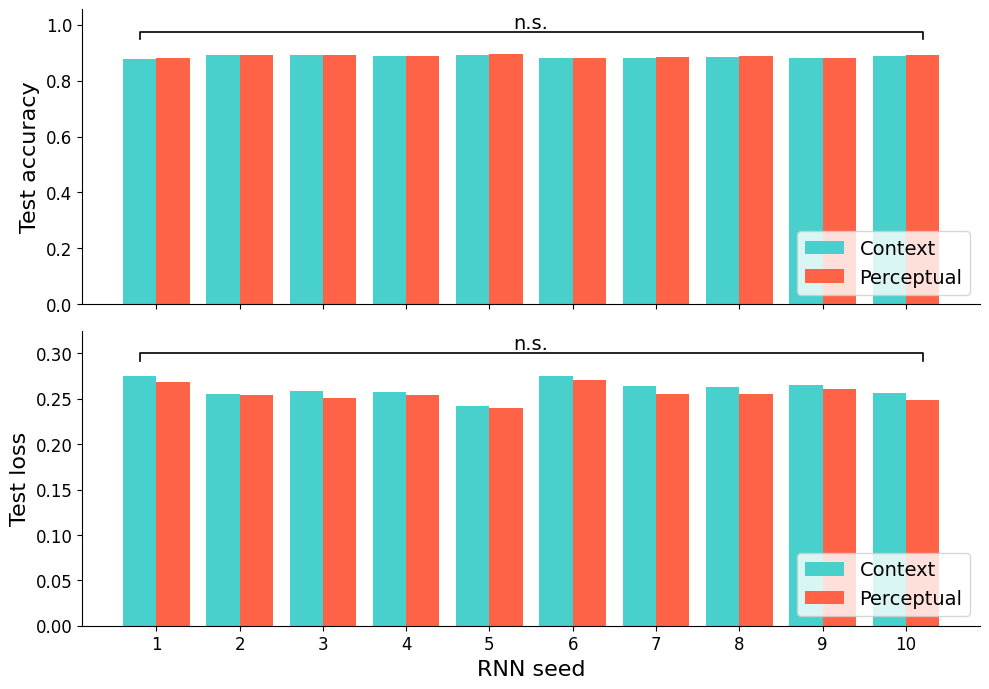

In [8]:
seeds = np.arange(1, N_SEEDS + 1)     # x positions = seed number 1..10
w = 0.4                                # bar width (two grouped bars per seed)

def annotate_sig(ax, x1, x2, p, data_top):
    """Horizontal significance bracket x1..x2 above the bars, marker via p_to_stars(p)."""
    span = data_top - ax.get_ylim()[0]
    y, h = data_top + 0.06*span, 0.03*span
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.2, color='black')
    ax.text((x1+x2)/2, y+h, p_to_stars(p), ha='center', va='bottom', fontsize=14)
    ax.set_ylim(top=y + 4*h)   # headroom so bracket + marker are not clipped

fig, (ax_acc, ax_loss) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# --- top: test accuracy (context left bar, perceptual right bar) ---
ax_acc.bar(seeds - w/2, test_acc['context'],    w, color=COLOR_CONTEXT,    label='Context')
ax_acc.bar(seeds + w/2, test_acc['perceptual'], w, color=COLOR_PERCEPTUAL, label='Perceptual')
ax_acc.set_ylabel('Test accuracy')
ax_acc.legend(loc='lower right')

# --- bottom: test loss (same coloring) ---
ax_loss.bar(seeds - w/2, test_loss['context'],    w, color=COLOR_CONTEXT,    label='Context')
ax_loss.bar(seeds + w/2, test_loss['perceptual'], w, color=COLOR_PERCEPTUAL, label='Perceptual')
ax_loss.set_ylabel('Test loss')
ax_loss.set_xlabel('RNN seed')
ax_loss.set_xticks(seeds)
ax_loss.legend(loc='lower right')

# --- significance bracket (MWU context vs perceptual) on top of each panel ---
xl, xr = seeds[0] - w/2, seeds[-1] + w/2
annotate_sig(ax_acc,  xl, xr, p_acc,  max(test_acc['context'].max(),  test_acc['perceptual'].max()))
annotate_sig(ax_loss, xl, xr, p_loss, max(test_loss['context'].max(), test_loss['perceptual'].max()))

fig.tight_layout()
fig.savefig(f"{FIG_ACC_DIR}/test_accuracy_loss_bars.png", dpi=300)
plt.show()

## Figure 2: Time-resolved PID for all seeds
Compute the Gaussian MMI-PID at **every timestep** for all 10 CTRNNs of each task,
bipartition-averaged over 200 random 50/50 unit splits (same procedure as the existing
`gaussian_pid_rnn`). Cache to `all_time_PID_{context,perceptual}` shaped
`[n_seeds=10, T, n_atoms=5]` in bits (atom axis = `ATOMS`), persist to disk, then draw
one figure per seed (perceptual | context).

#### 2a. GPU-batched PID (validated against `gaussian_pid_rnn`)
The bottleneck in `gaussian_pid_rnn` is recomputing a fresh covariance for each of the
200 bipartitions at each of 115 timesteps. But at a given timestep the joint covariance
over *all* units + target is shared across bipartitions, so we compute it **once per
timestep** on the GPU and only batch the small sub-block log-determinants per split. The
bipartition sequence is generated with the *same* regularization as `gaussian_pid_rnn`, so results
match to ~1e-10 bits (checked in 2b).

#### 2b. Sanity check vs the reference implementation
Run one seed through both paths on a handful of timesteps and confirm the GPU result
matches `gaussian_pid_rnn` to within numerical noise (< 1e-6 bits). This justifies using
the fast path for all 20 CTRNNs. Uncomment only if you want to re-run the check; it takes 1-3 min and not needed for normal operation.

In [9]:
# # ----- Uncomment only to validate again -----
# _H = load_activations('context', '01'); _Y = load_coherences('context', '01')
# _gpu = gaussian_pid_rnn_gpu(_H, _Y, n_bip=200, seed=SEED_ANALYSIS, reg=1e-5)
# _ref = gaussian_pid_rnn(activations=_H, target=_Y, timestep=None, bipartitions='random',
#                         n_bipartitions=200, seed=SEED_ANALYSIS, log_base=2, regularization=1e-5)
# _ref_arr = np.stack([_ref['redundancy'] + _ref['unique1'] + _ref['unique2'] + _ref['synergy'],
#                      _ref['redundancy'], _ref['unique1'], _ref['unique2'], _ref['synergy']], axis=1)
# print(f"max |GPU - reference| over all timesteps/atoms = {np.abs(_gpu - _ref_arr).max():.2e} bits")
# assert np.abs(_gpu - _ref_arr).max() < 1e-6, "GPU PID diverges from reference!"
# print("OK - GPU PID reproduces gaussian_pid_rnn.")
# # ----- Uncomment only to validate again -----

#### 2c. Compute (or load) the cached PID arrays
For each task, run the time-resolved PID over all 10 seeds into
`all_time_PID_{task}` of shape `[n_seeds, T, 5]` (bits, atom order = `ATOMS`). If the
`.npy` caches already exist they are loaded instead of recomputed. Each array is
persisted with a JSON **sidecar** documenting axis meaning, atom order and units.

In [10]:
def compute_all_time_pid(task):
    """Time-resolved PID for all seeds of a task -> (n_seeds, T, 5) in bits."""
    out = np.zeros((N_SEEDS, TOTAL_TIMESTEPS, len(ATOMS)))
    for i, s in enumerate(SEED_IDS):
        H, Y = load_activations(task, s), load_coherences(task, s)
        out[i] = gaussian_pid_rnn_gpu(H, Y, n_bip=200, seed=SEED_ANALYSIS, reg=1e-5)
        print(f"  {task:11s} CTRNN_{s}  synergy@DECISION_T = {out[i, DECISION_T, 4]:.4f} bits")
    return out

def save_pid(arr, task):
    """Persist the array + a JSON sidecar describing its axes/atoms/units."""
    np.save(f"{PID_OUT_DIR}/{task}/all_time_PID.npy", arr)
    meta = {
        "array_file": "all_time_PID.npy",
        "shape": list(arr.shape),
        "axes": ["seed 0..9 = CTRNN_01..CTRNN_10",
                 f"timestep 0..{TOTAL_TIMESTEPS-1} ({MS_PER_STEP} ms each)",
                 "atom"],
        "atom_order": ATOMS,
        "units": "bits",
        "decision_t": DECISION_T,
        "note": ("Gaussian MMI-PID, bipartition-averaged over 200 random 50/50 unit "
                 "splits (seed=%d). total_mi = redundancy+unique1+unique2+synergy." % SEED_ANALYSIS),
    }
    with open(f"{PID_OUT_DIR}/{task}/all_time_PID_meta.json", "w") as f:
        json.dump(meta, f, indent=2)

ctx_path = f"{PID_OUT_DIR}/context/all_time_PID.npy"
per_path = f"{PID_OUT_DIR}/perceptual/all_time_PID.npy"
if os.path.exists(ctx_path) and os.path.exists(per_path):
    all_time_PID_context    = np.load(ctx_path)      # cached: skip recomputation
    all_time_PID_perceptual = np.load(per_path)
    print("Loaded cached PID arrays:", all_time_PID_context.shape, all_time_PID_perceptual.shape)
else:
    t0 = time.time()
    print("Computing perceptual...");  all_time_PID_perceptual = compute_all_time_pid('perceptual')
    print("Computing context...");     all_time_PID_context    = compute_all_time_pid('context')
    save_pid(all_time_PID_perceptual, 'perceptual')
    save_pid(all_time_PID_context,    'context')
    print(f"Done in {time.time()-t0:.1f}s. Saved arrays + sidecars to {PID_OUT_DIR}/")

Loaded cached PID arrays: (10, 115, 5) (10, 115, 5)


#### 2d. Per-seed time-resolved PID figures
One figure per seed: **left = perceptual**, **right = context**, sharing the y-axis. All
five atoms are drawn with their distinct `ATOM_COLORS` and a labeled legend; the panel's
**task color** tints the stimulus-period shading and the axis spines so the two tasks are
identifiable without titles. Following `plot_pid_ax`, a dashed red line marks the decision
time and the stimulus window is shaded. x = Time (ms), y = Information (bits). The 20
figures are saved (not shown).

In [11]:
def plot_pid_ax(ax, pid, task_color, task_name):
    """Draw the 5 PID atoms (bits) over time (ms) on one axis, notebook-06 style."""
    t_ms = steps_to_ms(np.arange(TOTAL_TIMESTEPS))
    # atom curves: synergy & redundancy emphasized (lw=3), uniques thinner, total dotted
    ax.plot(t_ms, pid[:, 1], color=ATOM_COLORS['redundancy'], lw=3.0, label='Redundancy')
    ax.plot(t_ms, pid[:, 4], color=ATOM_COLORS['synergy'],    lw=3.0, label='Synergy')
    ax.plot(t_ms, pid[:, 2], color=ATOM_COLORS['unique1'], lw=1.5, label='Unique 1')
    ax.plot(t_ms, pid[:, 3], color=ATOM_COLORS['unique2'], lw=1.5, label='Unique 2')
    ax.plot(t_ms, pid[:, 0], color=ATOM_COLORS['total_mi'], lw=1.5, ls=':', label='Total MI')
    # decision-time marker + stimulus-period shading (tinted with the task color)
    ax.axvline(DECISION_T * MS_PER_STEP, color='red', ls='--', label='Decision time')
    ax.axvspan(STIM_START_STEP * MS_PER_STEP, DECISION_T * MS_PER_STEP,
               color=task_color, alpha=0.12)
    # task-colored spines to identify the panel's task without a title
    for side in ('left', 'bottom'):
        ax.spines[side].set_linewidth(2.0)
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('Information (bits)')

    # subplot title = task name + seed id (e.g. "Perceptual CTRNN_01")
    ax.set_title(f"{task_name.title()} (CTRNN_{SEED_IDS[i]})")

for i, s in enumerate(SEED_IDS):
    fig, (axL, axR) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
    plot_pid_ax(axL, all_time_PID_perceptual[i], COLOR_PERCEPTUAL, TASKS[0])   # left = perceptual
    plot_pid_ax(axR, all_time_PID_context[i],    COLOR_CONTEXT, TASKS[1])      # right = context
    axL.legend(loc='upper left')
    fig.tight_layout()
    fig.savefig(f"{FIG_PID_DIR}/CTRNN_{s}.png", dpi=300)
    plt.close(fig)                                                   # 20 figures -> don't show
print(f"Saved {N_SEEDS} per-seed PID figures to {FIG_PID_DIR}/")

Saved 10 per-seed PID figures to ../figures/all_time_pid/


## Figure 3: Mean +/- SD time-resolved PID (across seeds)
Collapse the 10 per-seed PID curves (in Fig 2, **not recomputed**) into a single
mean +/- SD trace per task. For each task we average every PID atom across the 10 CTRNNs
(mean = solid line) and shade +/-1 SD across seeds (band). All five atoms (incl.
`total_mi`) are drawn in their `ATOM_COLORS` with a labeled legend; the task color tints
the stimulus shading. Laid out as two shared-y subplots (perceptual | context), each
titled with its task name as in Fig 2.

- Save: `figures/mean_all_time_pid/mean_all_time_pid.png`

#### 3a. Aggregate the cached per-seed PID (mean & SD across the 10 seeds)
Reduce the cached `all_time_PID_{task}` `[n_seeds, T, 5]` (from Fig 2) along the seed
axis into per-task **mean** and **SD** `[T, 5]` arrays. SD uses `ddof=1` (sample SD of
the 10 seeds). No PID is recomputed here.

In [12]:
# Aggregate the cached per-seed PID (from Fig 2) across the 10 seeds. NO PID recompute:
# we only take mean/SD of the already-cached [n_seeds, T, 5] arrays along the seed axis.
mean_time_PID = {
    'perceptual': all_time_PID_perceptual.mean(axis=0),        # (T, 5) mean over seeds
    'context':    all_time_PID_context.mean(axis=0),
}
# SD across seeds with ddof=1 (sample SD of the 10 seeds) -> the band is the unbiased
# estimate of per-atom spread across networks.
sd_time_PID = {
    'perceptual': all_time_PID_perceptual.std(axis=0, ddof=1),  # (T, 5) SD over seeds
    'context':    all_time_PID_context.std(axis=0, ddof=1),
}

# output dir for the single (two-panel) mean-PID figure
FIG_MEAN_PID_DIR = "../figures/mean_all_time_pid"
os.makedirs(FIG_MEAN_PID_DIR, exist_ok=True)

# quick check: mean +/- SD of synergy at decision time per task (bits)
for t in TASKS:
    m = mean_time_PID[t][DECISION_T, 4]                          # atom idx 4 = synergy
    s = sd_time_PID[t][DECISION_T, 4]
    print(f"{t:11s} synergy@DECISION_T = {m:.4f} +/- {s:.4f} bits (mean +/- SD over {N_SEEDS} seeds)")

perceptual  synergy@DECISION_T = 0.0066 +/- 0.0009 bits (mean +/- SD over 10 seeds)
context     synergy@DECISION_T = 0.0178 +/- 0.0029 bits (mean +/- SD over 10 seeds)


#### 3b. Draw & save the mean +/- SD figure
A single figure with two shared-y subplots (**left = perceptual**, **right = context**),
each titled with its task name as in Fig 2: the five mean atom curves with +/-1 SD bands,
a task-tinted stimulus shading + decision line, and a labeled legend. x = Time (ms),
y = Information (bits). Saved as PNG (dpi=300) to `figures/mean_all_time_pid/`.

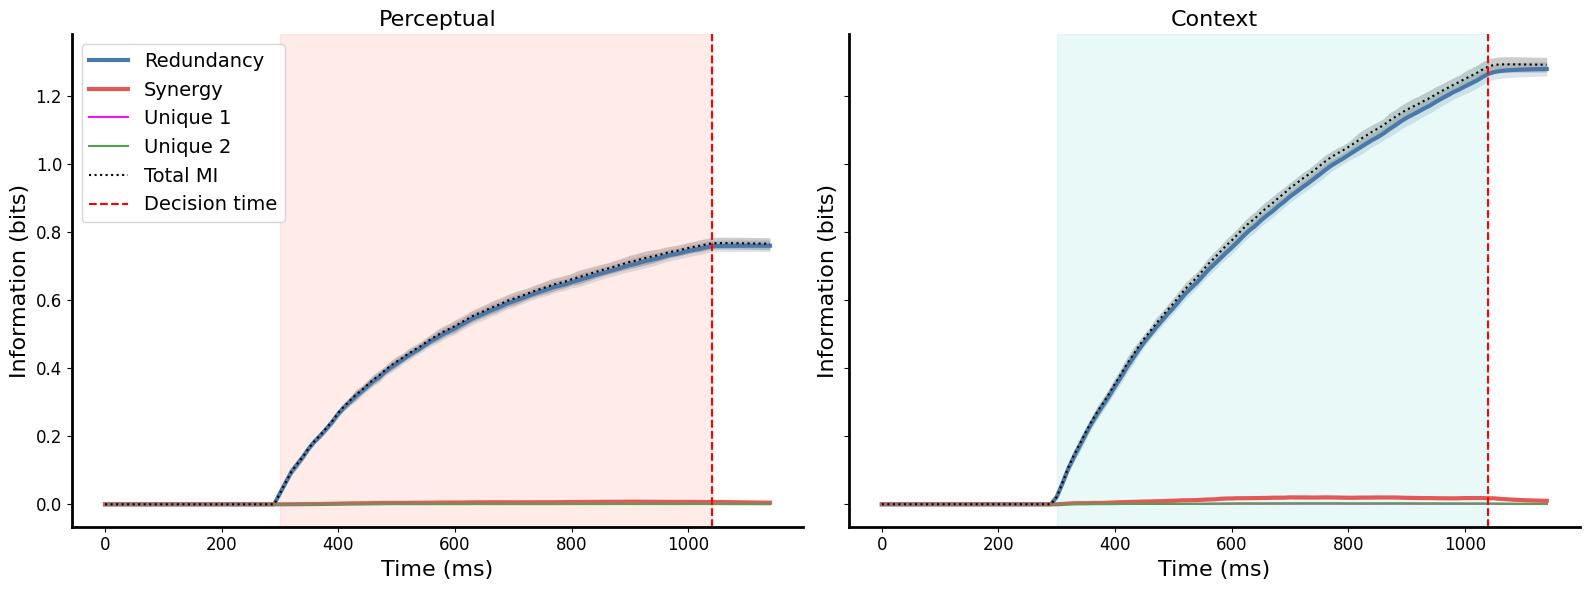

Saved mean +/- SD PID figure to ../figures/mean_all_time_pid/mean_all_time_pid.png


In [13]:
def plot_mean_sd_pid_ax(ax, mean_pid, sd_pid, task_color, task_name):
    """Mean (line) +/- SD (band) of the 5 PID atoms over time (ms), notebook-06 style.

    Atoms keep their distinct ATOM_COLORS (so the labeled legend separates them); the
    task color tints the stimulus shading and the panel is titled with its task name as
    in Fig 2. total_mi stays dotted per the global 'Plotting conventions'.
    """
    t_ms = steps_to_ms(np.arange(TOTAL_TIMESTEPS))          # x axis in ms
    # (atom name, atom-axis index, linewidth, alpha, linestyle, legend label)
    specs = [
        ('redundancy', 1, 3.0, 1.0, '-', 'Redundancy'),    # emphasized (lw=3)
        ('synergy',    4, 3.0, 1.0, '-', 'Synergy'),        # emphasized (lw=3)
        ('unique1',    2, 1.5, 1.0, '-', 'Unique 1'),
        ('unique2',    3, 1.5, 1.0, '-', 'Unique 2'),
        ('total_mi',   0, 1.5, 1.0, ':', 'Total MI'),       # dotted (global convention)
    ]
    for name, j, lw, a, ls, lab in specs:
        c = ATOM_COLORS[name]
        # mean across seeds as a solid (total_mi: dotted) line
        ax.plot(t_ms, mean_pid[:, j], color=c, lw=lw, alpha=a, ls=ls, label=lab)
        # +/-1 SD across seeds as a translucent shaded band in the same atom color
        ax.fill_between(t_ms, mean_pid[:, j] - sd_pid[:, j], mean_pid[:, j] + sd_pid[:, j],
                        color=c, alpha=0.20, linewidth=0)
    # decision-time marker + stimulus-period shading (tinted with the task color)
    ax.axvline(DECISION_T * MS_PER_STEP, color='red', ls='--', label='Decision time')
    ax.axvspan(STIM_START_STEP * MS_PER_STEP, DECISION_T * MS_PER_STEP,
               color=task_color, alpha=0.12)
    for side in ('left', 'bottom'):
        ax.spines[side].set_linewidth(2.0)
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('Information (bits)')
    ax.set_title(task_name.title())                        # subplot title = task name

# single figure: left = perceptual, right = context, shared y-axis (as in Fig 2)
fig, (axL, axR) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
plot_mean_sd_pid_ax(axL, mean_time_PID['perceptual'], sd_time_PID['perceptual'],
                    COLOR_PERCEPTUAL, TASKS[0])            # left = perceptual
plot_mean_sd_pid_ax(axR, mean_time_PID['context'],    sd_time_PID['context'],
                    COLOR_CONTEXT, TASKS[1])               # right = context
axL.legend(loc='upper left')                               # labeled legend for the 5 atoms
fig.tight_layout()
fig.savefig(f"{FIG_MEAN_PID_DIR}/mean_all_time_pid.png", dpi=300)
plt.show()
print(f"Saved mean +/- SD PID figure to {FIG_MEAN_PID_DIR}/mean_all_time_pid.png")

#### 3c. Normality (Shapiro-Wilk) at decision time
For each of the 5 atoms x 2 tasks, test whether the **per-seed** values at `DECISION_T`
(n = 10) are normally distributed. Shapiro-Wilk is the correct, higher-power choice for
small n with unknown (not known-in-advance) parameters.

**Multiple comparisons.** The family is 5 atoms x 2 tasks = 10 tests, so we Bonferroni-
correct to alpha = 0.05 / 10 = 0.005. The factor is the *number of tests in the family*,
not the sample size: n = 10 sets each test's power, the 10 tests set the correction.
`total_mi` is included (per project preference) even though it is the deterministic sum
of the other four atoms.

**Caveat.** At n = 10 every normality test is underpowered, so a non-significant SW
result is only weak evidence of normality.

Results (statistic, p, corrected threshold, pass/fail) are appended to the running
`results/pid_outputs/stats_summary.csv`.

In [14]:
# --- Bonferroni family: 4 INDEPENDENT atoms x 2 tasks = 8 normality tests ---------
# total_mi = redundancy + unique1 + unique2 + synergy is the DETERMINISTIC sum of the
# other four atoms, so it is NOT an independent hypothesis and is excluded from the
# correction family; it is still tested but scored uncorrected (k=1). The correction
# factor is the number of INDEPENDENT tests: 4 atoms x 2 tasks = 8.
SW_COMPARISON_ATOMS = ['redundancy', 'unique1', 'unique2', 'synergy']   # exclude total_mi
N_SW_TESTS    = len(SW_COMPARISON_ATOMS) * len(TASKS)   # 8
SW_ALPHA      = 0.05
SW_ALPHA_CORR = SW_ALPHA / N_SW_TESTS            # 0.00625 corrected threshold

# Persistent accumulator for results/pid_outputs/stats_summary.csv, built across the
# whole notebook. Keyed by a unique test id so re-running a cell overwrites (never dups)
# and no stats variable is ever reused between tests.
if 'stats_summary_records' not in globals():
    stats_summary_records = {}

# Decision-time per-seed atom values, sliced from the cached Fig-2 arrays (NO recompute).
decision_pid = {
    'perceptual': all_time_PID_perceptual[:, DECISION_T, :],   # (n_seeds=10, 5)
    'context':    all_time_PID_context[:, DECISION_T, :],
}

print(f"Shapiro-Wilk normality at DECISION_T (n={N_SEEDS} seeds), "
      f"Bonferroni x{N_SW_TESTS} -> corrected alpha = {SW_ALPHA_CORR:g}\n")
for task in TASKS:
    for j, atom in enumerate(ATOMS):                      # all 5 atoms incl. total_mi
        vals_sw = decision_pid[task][:, j]               # (10,) per-seed values @ DECISION_T
        sw_stat, sw_p = stats.shapiro(vals_sw)           # SW: high-power for small n
        # total_mi is excluded from the correction family (dependent quantity) -> scored
        # uncorrected (k=1); the 4 independent atoms use the k=8 corrected threshold.
        sw_bonf_k    = 1 if atom == 'total_mi' else N_SW_TESTS
        sw_alpha_row = SW_ALPHA if atom == 'total_mi' else SW_ALPHA_CORR
        sw_pass = sw_p >= sw_alpha_row                   # fail to reject -> "normal"
        # unique key per (test, task, atom) -> no stats variable is ever overwritten
        stats_summary_records[f"shapiro_{task}_{atom}"] = {
            'test': 'Shapiro-Wilk normality',
            'task': task,
            'atom': atom,
            'n': int(len(vals_sw)),
            'statistic': float(sw_stat),
            'p_value': float(sw_p),
            'alpha_corrected': sw_alpha_row,
            'bonferroni_factor': sw_bonf_k,
            'pass_normality': bool(sw_pass),
        }
        print(f"  {task:11s} {atom:10s}  W={sw_stat:.3f}  p={sw_p:.4f}  "
              f"-> {'normal (fail to reject)' if sw_pass else 'NON-normal (reject)'}")

# --- write the accumulated stats out to the running CSV --------------------------
# base column order first, then any extra columns future tests may add (robust union).
_base_cols = ['test', 'task', 'atom', 'n', 'statistic', 'p_value',
              'alpha_corrected', 'bonferroni_factor', 'pass_normality']
_extra = sorted({k for r in stats_summary_records.values() for k in r} - set(_base_cols))
csv_path = f"{PID_OUT_DIR}/stats_summary.csv"
with open(csv_path, 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=_base_cols + _extra)
    writer.writeheader()
    for key in sorted(stats_summary_records):            # deterministic row order
        writer.writerow(stats_summary_records[key])
print(f"\nWrote {len(stats_summary_records)} stat rows to {csv_path}")
print("Caveat: at n=10 all normality tests are underpowered, so a non-significant SW "
      "result is only weak evidence of normality.")

Shapiro-Wilk normality at DECISION_T (n=10 seeds), Bonferroni x8 -> corrected alpha = 0.00625

  perceptual  total_mi    W=0.820  p=0.0251  -> NON-normal (reject)
  perceptual  redundancy  W=0.818  p=0.0237  -> normal (fail to reject)
  perceptual  unique1     W=0.906  p=0.2549  -> normal (fail to reject)
  perceptual  unique2     W=0.823  p=0.0274  -> normal (fail to reject)
  perceptual  synergy     W=0.859  p=0.0739  -> normal (fail to reject)
  context     total_mi    W=0.948  p=0.6435  -> normal (fail to reject)
  context     redundancy  W=0.926  p=0.4113  -> normal (fail to reject)
  context     unique1     W=0.801  p=0.0149  -> normal (fail to reject)
  context     unique2     W=0.897  p=0.2010  -> normal (fail to reject)
  context     synergy     W=0.947  p=0.6294  -> normal (fail to reject)

Wrote 12 stat rows to ../results/pid_outputs/stats_summary.csv
Caveat: at n=10 all normality tests are underpowered, so a non-significant SW result is only weak evidence of normality.


## Figure 4: Decision-time PID (context vs perceptual)
At `DECISION_T` each atom has 10 per-seed values per task. We compare the two tasks
**per atom** with a two-sided Mann-Whitney U test whose p-values are Bonferroni-corrected
(x4 across the 4 atoms), then show the distributions two ways: per-atom **violins**
(individual seeds overlaid, a bold cross-bar at the median) and, as a quick-read variant,
grouped **mean +/- SD bars**. `total_mi` is included as one of the five atoms. Nothing is
recomputed: we reuse the cached decision-time per-seed values (`decision_pid`, Fig 3c) and
the Fig-3 across-seed mean/SD (`mean_time_PID`/`sd_time_PID`).

#### 4a. Per-atom Mann-Whitney U (context vs perceptual) at decision time
Build `decision_atoms[task][atom]` (10 per-seed values) by slicing the cached
decision-time array, then run one two-sided MWU per atom (n=10 vs 10). Family = 4 atoms,
so we **Bonferroni-correct the p-values** (x4) and feed those to the global
`p_to_stars` marker rules. Store the U statistic, raw p, corrected p and the marker per atom, and append each atom's row (U, raw p, corrected p,
context mean/SD, perceptual mean/SD) to the running `stats_summary.csv`.

In [15]:
# Per-atom decision-time values: task -> atom -> (10,) per-seed slice of the cached
# Fig-2/3c arrays (NO recompute). decision_pid (Fig 3c) is (n_seeds=10, 5) per task.
decision_atoms = {
    task: {atom: decision_pid[task][:, j] for j, atom in enumerate(ATOMS)}
    for task in TASKS
}

# Display names for the 5 atoms (as in Fig 3), used for violin titles & bar x-ticks.
ATOM_NAMES = {'total_mi': 'Total MI', 'redundancy': 'Redundancy',
              'unique1': 'Unique 1', 'unique2': 'Unique 2', 'synergy': 'Synergy'}

# Bonferroni correction for the MWU family. total_mi = redundancy + unique1 + unique2 +
# synergy is the DETERMINISTIC sum of the other four atoms, so it carries no independent
# hypothesis and is EXCLUDED from the correction family: the corrected COMPARISON family
# is exactly the four independent atoms (k=4, alpha = 0.05/4 = 0.0125). total_mi is still
# run but reported separately as an UNCORRECTED magnitude result (k=1, alpha=0.05) -- it is
# the primary magnitude effect, just excluded from the correction denominator. We correct
# the p-values (x k) and feed them to the GLOBAL p_to_stars() rules (correcting both the
# p-value and the threshold would be correcting twice).
MWU_COMPARISON_ATOMS = ['redundancy', 'unique1', 'unique2', 'synergy']   # k=4 corrected family
MWU_BONFERRONI = len(MWU_COMPARISON_ATOMS)     # 4
MWU_ALPHA      = 0.05                           # significance level (markers via p_to_stars)
MWU_ALPHA_CORR = MWU_ALPHA / MWU_BONFERRONI     # 0.0125 corrected threshold (comparison family)

# One two-sided MWU per atom (context vs perceptual). Distinct dicts -> no stats variable
# is ever reused between atoms/tests.
mwu_ustats     = {}   # atom -> U statistic
mwu_pvals      = {}   # atom -> raw p-value
mwu_pvals_bonf = {}   # atom -> Bonferroni-corrected p (drives the significance markers)
print(f"Decision-time MWU (context vs perceptual): comparison family k={MWU_BONFERRONI} "
      f"(alpha={MWU_ALPHA_CORR:g}); total_mi separate & uncorrected (magnitude)\n")
for j, atom in enumerate(ATOMS):
    ctx_vals = decision_atoms['context'][atom]        # (10,) context per-seed values
    per_vals = decision_atoms['perceptual'][atom]     # (10,) perceptual per-seed values
    u_atom, p_atom = stats.mannwhitneyu(ctx_vals, per_vals, alternative='two-sided')
    # total_mi excluded from the Bonferroni family (dependent sum) -> uncorrected (k=1);
    # the 4 real atoms form the corrected comparison family (k=4).
    if atom == 'total_mi':
        mwu_family, mwu_bonf_k, mwu_alpha_row = 'magnitude', 1, MWU_ALPHA
    else:
        mwu_family, mwu_bonf_k, mwu_alpha_row = 'comparison', MWU_BONFERRONI, MWU_ALPHA_CORR
    p_atom_bonf = min(p_atom * mwu_bonf_k, 1.0)       # Bonferroni-corrected p (capped at 1)
    mwu_ustats[atom]     = float(u_atom)
    mwu_pvals[atom]      = float(p_atom)
    mwu_pvals_bonf[atom] = float(p_atom_bonf)
    # reuse the Fig-3 across-seed mean/SD at DECISION_T (NOT recomputed here)
    ctx_mean, ctx_sd = mean_time_PID['context'][DECISION_T, j],    sd_time_PID['context'][DECISION_T, j]
    per_mean, per_sd = mean_time_PID['perceptual'][DECISION_T, j], sd_time_PID['perceptual'][DECISION_T, j]
    # unique key per atom -> row is overwritten on re-run, never duplicated/reused
    stats_summary_records[f"mwu_decision_{atom}"] = {
        'test': 'Mann-Whitney U (context vs perceptual) @ DECISION_T',
        'task': 'context_vs_perceptual',
        'atom': atom,
        'family': mwu_family,
        'n': N_SEEDS,
        'statistic': float(u_atom),
        'p_value': float(p_atom),
        'p_value_bonferroni': float(p_atom_bonf),
        'alpha_corrected': float(mwu_alpha_row),
        'bonferroni_factor': mwu_bonf_k,
        'context_mean': float(ctx_mean),    'context_sd': float(ctx_sd),
        'perceptual_mean': float(per_mean), 'perceptual_sd': float(per_sd),
        'significant': bool(p_atom_bonf < mwu_alpha_row),
    }
    print(f"  {atom:10s}  [{mwu_family:10s} k={mwu_bonf_k}]  U={u_atom:5.1f}  p={p_atom:.4g}  "
          f"p_bonf={p_atom_bonf:.4g}  {p_to_stars(p_atom_bonf):>4s}  "
          f"(ctx {ctx_mean:.4f}+/-{ctx_sd:.4f} | per {per_mean:.4f}+/-{per_sd:.4f})")

# --- re-write the running stats CSV so Figure-4 rows are persisted (same union-of-
#     columns pattern as Fig 3c) ---
_base_cols = ['test', 'task', 'atom', 'n', 'statistic', 'p_value',
              'alpha_corrected', 'bonferroni_factor', 'pass_normality']
_extra = sorted({k for r in stats_summary_records.values() for k in r} - set(_base_cols))
csv_path = f"{PID_OUT_DIR}/stats_summary.csv"
with open(csv_path, 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=_base_cols + _extra)
    writer.writeheader()
    for key in sorted(stats_summary_records):            # deterministic row order
        writer.writerow(stats_summary_records[key])
print(f"\nWrote {len(stats_summary_records)} stat rows to {csv_path}")

Decision-time MWU (context vs perceptual): comparison family k=4 (alpha=0.0125); total_mi separate & uncorrected (magnitude)

  total_mi    [magnitude  k=1]  U=100.0  p=0.0001827  p_bonf=0.0001827   ***  (ctx 1.2857+/-0.0218 | per 0.7662+/-0.0172)
  redundancy  [comparison k=4]  U=100.0  p=0.0001827  p_bonf=0.0007307   ***  (ctx 1.2641+/-0.0212 | per 0.7579+/-0.0167)
  unique1     [comparison k=4]  U=100.0  p=0.0001827  p_bonf=0.0007307   ***  (ctx 0.0020+/-0.0005 | per 0.0008+/-0.0002)
  unique2     [comparison k=4]  U=100.0  p=0.0001827  p_bonf=0.0007307   ***  (ctx 0.0018+/-0.0003 | per 0.0008+/-0.0002)
  synergy     [comparison k=4]  U=100.0  p=0.0001827  p_bonf=0.0007307   ***  (ctx 0.0178+/-0.0029 | per 0.0066+/-0.0009)

Wrote 17 stat rows to ../results/pid_outputs/stats_summary.csv


#### 4b. Decision-time PID violins (context vs perceptual)
One row x 5 columns, one atom per subplot. Each panel shows a **Perceptual (left) vs
Context (right)** violin (task colors) with the 10 seed points overlaid and a bold
horizontal cross-bar at the **median** (more visible than the usual dot). An L-shaped
significance bracket + marker (global `p_to_stars` on the Bonferroni-corrected p) is drawn
above a panel **only** when that atom is significant. Subplot titles = atom names (as in
Fig 3); all fonts follow the global plotting conventions. Saved to
`figures/pid_decision_time/decision_time_pid_violin.png`.

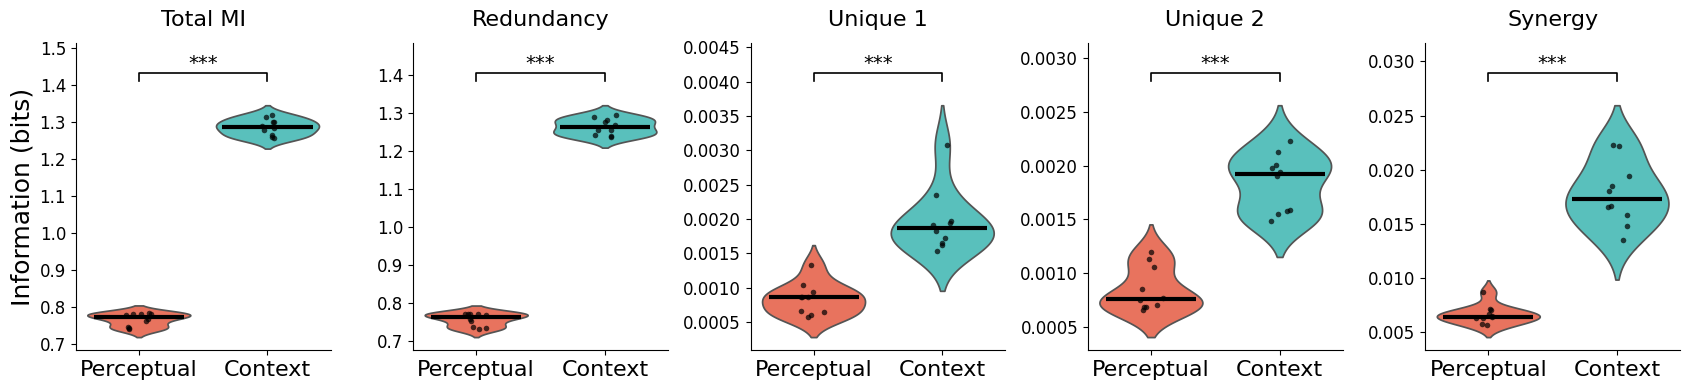

Saved decision-time violin figure to ../figures/pid_decision_time/decision_time_pid_violin.png


In [16]:
# output dir for the two decision-time figures
FIG_DEC_PID_DIR = "../figures/pid_decision_time"
os.makedirs(FIG_DEC_PID_DIR, exist_ok=True)

order = ['Perceptual', 'Context']     # perceptual ALWAYS left, context ALWAYS right
fig, axs = plt.subplots(1, 5, figsize=(17, 4))
for col, atom in enumerate(ATOMS):
    ctx = decision_atoms['context'][atom]        # (10,) context per-seed values
    per = decision_atoms['perceptual'][atom]     # (10,) perceptual per-seed values
    # tidy long-form frame: one row per (task, seed) value
    df = pd.DataFrame({
        'Value': np.concatenate([per, ctx]),
        'Task':  ['Perceptual'] * len(per) + ['Context'] * len(ctx)})
    ax = axs[col]
    # violins in the two task colors (hue=Task keeps seaborn 0.13+ happy; inner=None so
    # we draw our own, more visible median bar instead of the default dot/box)
    sns.violinplot(data=df, x='Task', y='Value', order=order, hue='Task', hue_order=order,
                   palette={'Context': COLOR_CONTEXT, 'Perceptual': COLOR_PERCEPTUAL},
                   legend=False, inner=None, ax=ax)
    # individual seed points on top
    sns.stripplot(data=df, x='Task', y='Value', order=order, ax=ax,
                  color='black', size=4, alpha=0.7)
    # bold horizontal cross-bar at each task's MEDIAN (replaces the usual mean dot);
    # x positions follow `order`: 0 = perceptual (left), 1 = context (right)
    for x_pos, vals in zip((0, 1), (per, ctx)):
        ax.hlines(np.median(vals), x_pos - 0.35, x_pos + 0.35, color='black', lw=3, zorder=5)
    # significance bracket -- same L-shaped bracket as the bar plot (NOT an error-bar
    # |--|), drawn only when the Bonferroni-corrected p is significant; marker via p_to_stars
    if mwu_pvals_bonf[atom] < MWU_ALPHA:
        ylim = ax.get_ylim(); span = ylim[1] - ylim[0]
        y_br = ylim[1] + 0.05 * span; leg = 0.03 * span
        ax.plot([0, 0, 1, 1], [y_br, y_br + leg, y_br + leg, y_br], lw=1.2, color='black')
        ax.text(0.5, y_br + leg, p_to_stars(mwu_pvals_bonf[atom]),
                ha='center', va='bottom', color='black', fontsize=14)
        ax.set_ylim(top=y_br + 5 * leg)                    # headroom (no clip)
    # subplot title = atom NAME (Fig-3 style); fonts inherit the global conventions
    ax.set_title(ATOM_NAMES[atom], pad=12)
    ax.set_ylabel('Information (bits)' if col == 0 else '')
    # Increase yaxis label name font size
    ax.yaxis.label.set_size(18)
    ax.set_xlabel('')
    # Increase xaixs labels font size
    ax.tick_params(axis='x', labelsize=16)
plt.tight_layout()
fig.savefig(f"{FIG_DEC_PID_DIR}/decision_time_pid_violin.png", dpi=300)
plt.show()
print(f"Saved decision-time violin figure to {FIG_DEC_PID_DIR}/decision_time_pid_violin.png")

#### 4c. Decision-time PID bars (quick-read variant)
The same decision-time statistics as the violins, shown as grouped **mean +/- SD** bars:
for each of the 4 atoms a Perceptual (left) and a Context (right) bar (task colors), an SD
error bar, and the mean value printed above it (fontsize 12). A horizontal bracket with
the significance marker (global `p_to_stars` on the Bonferroni-corrected p) sits above each
atom's pair. Reuses the Fig-3 mean/SD and the 4a MWU p-values (nothing recomputed). Saved
to `figures/pid_decision_time/decision_time_pid_bars.png`.

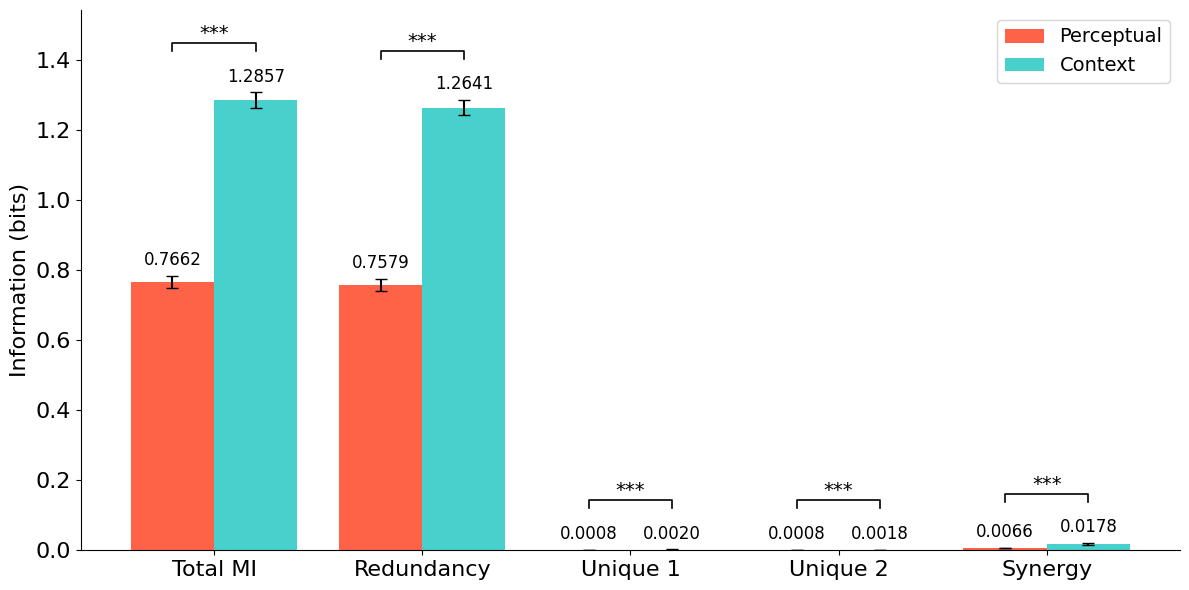

Saved decision-time bar figure to ../figures/pid_decision_time/decision_time_pid_bars.png


In [17]:
x    = np.arange(len(ATOMS))    # one group per atom (x tick), atom-ordered
wbar = 0.4                      # width of each of the two grouped bars

# Fig-3 across-seed mean/SD at DECISION_T (reused, NOT recomputed), atom-ordered.
ctx_means = np.array([mean_time_PID['context'][DECISION_T, j]    for j in range(len(ATOMS))])
ctx_sds   = np.array([sd_time_PID['context'][DECISION_T, j]      for j in range(len(ATOMS))])
per_means = np.array([mean_time_PID['perceptual'][DECISION_T, j] for j in range(len(ATOMS))])
per_sds   = np.array([sd_time_PID['perceptual'][DECISION_T, j]   for j in range(len(ATOMS))])

fig, ax = plt.subplots(figsize=(12, 6))
# grouped bars with SD error bars (perceptual ALWAYS left, context ALWAYS right)
ax.bar(x - wbar/2, per_means, wbar, yerr=per_sds, capsize=4,
       color=COLOR_PERCEPTUAL, label='Perceptual')
ax.bar(x + wbar/2, ctx_means, wbar, yerr=ctx_sds, capsize=4,
       color=COLOR_CONTEXT,    label='Context')

# vertical offsets scaled to the data so labels/brackets never clip
ymax_data = max((ctx_means + ctx_sds).max(), (per_means + per_sds).max())
voff = 0.015 * ymax_data        # gap between error-bar cap and the printed value
boff = 0.09  * ymax_data        # height of the significance bracket above the pair

# mean value printed just above each error bar (fontsize 12 per spec)
for xb, m, s in (list(zip(x - wbar/2, per_means, per_sds)) +
                 list(zip(x + wbar/2, ctx_means, ctx_sds))):
    ax.text(xb, m + s + voff, f"{m:.4f}", ha='center', va='bottom', fontsize=12)

# per-atom significance bracket (Bonferroni-corrected p -> global p_to_stars) over each pair
for i, atom in enumerate(ATOMS):
    pair_top = max(ctx_means[i] + ctx_sds[i], per_means[i] + per_sds[i])
    y_br = pair_top + boff
    ax.plot([x[i] - wbar/2, x[i] - wbar/2, x[i] + wbar/2, x[i] + wbar/2],
            [y_br, y_br + 0.2*boff, y_br + 0.2*boff, y_br], lw=1.2, color='black')
    ax.text(x[i], y_br + 0.2*boff, p_to_stars(mwu_pvals_bonf[atom]),
            ha='center', va='bottom', fontsize=14)

ax.set_ylim(top=ymax_data + 2*boff)         # headroom for values + bracket + star
ax.set_xticks(x); ax.set_xticklabels([ATOM_NAMES[a] for a in ATOMS])  # atom names, not keys
ax.set_ylabel('Information (bits)')
ax.tick_params(axis='x', labelsize=16)   # increase x-axis tick font size
ax.tick_params(axis='y', labelsize=16)   # increase y-axis tick font size
ax.legend(loc='upper right')
plt.tight_layout()
fig.savefig(f"{FIG_DEC_PID_DIR}/decision_time_pid_bars.png", dpi=300)
plt.show()
print(f"Saved decision-time bar figure to {FIG_DEC_PID_DIR}/decision_time_pid_bars.png")

In [18]:
# Compute difference redundancy - synergy at DECISION_T for each seed, then average across seeds. Do this for each task. 
# This is the "redundancy-synergy tradeoff"
redundancy_synergy_tradeoff = {
    task: decision_pid[task][:, 1] - decision_pid[task][:, 4]  # redundancy - synergy
    for task in TASKS
}
# Print the mean and standard deviation of the redundancy-synergy tradeoff for each task
for task in TASKS:
    mean_tradeoff = redundancy_synergy_tradeoff[task].mean()
    std_tradeoff = redundancy_synergy_tradeoff[task].std(ddof=1)
    print(f"{task:11s} redundancy-synergy tradeoff @ DECISION_T = {mean_tradeoff:.4f} +/- {std_tradeoff:.4f} bits (mean +/- SD over {N_SEEDS} seeds)")

perceptual  redundancy-synergy tradeoff @ DECISION_T = 0.7512 +/- 0.0164 bits (mean +/- SD over 10 seeds)
context     redundancy-synergy tradeoff @ DECISION_T = 1.2463 +/- 0.0212 bits (mean +/- SD over 10 seeds)


In [19]:
# Compute normalized PID atoms by total MI
normalized_pid = {
    task: decision_pid[task] / decision_pid[task][:, 0][:, np.newaxis]  # divide each atom by total MI
    for task in TASKS
}  

# Print the mean and standard deviation of the normalized PID atoms for each task
for task in TASKS:
    print(f"\n{task:11s} normalized PID atoms @ DECISION_T (mean +/- SD over {N_SEEDS} seeds):")
    for j, atom in enumerate(ATOMS):
        mean_norm = normalized_pid[task][:, j].mean()
        std_norm = normalized_pid[task][:, j].std(ddof=1)
        print(f"  {atom:10s}: {mean_norm:.4f} +/- {std_norm:.4f}")


perceptual  normalized PID atoms @ DECISION_T (mean +/- SD over 10 seeds):
  total_mi  : 1.0000 +/- 0.0000
  redundancy: 0.9891 +/- 0.0013
  unique1   : 0.0011 +/- 0.0003
  unique2   : 0.0011 +/- 0.0003
  synergy   : 0.0087 +/- 0.0010

context     normalized PID atoms @ DECISION_T (mean +/- SD over 10 seeds):
  total_mi  : 1.0000 +/- 0.0000
  redundancy: 0.9832 +/- 0.0027
  unique1   : 0.0015 +/- 0.0003
  unique2   : 0.0014 +/- 0.0002
  synergy   : 0.0138 +/- 0.0022
